# Experimental activity measurements — Figure 4A/B

This notebook retains the two final plotting sections of the original experimental-data notebook. Means and standard deviations were pasted into that notebook; the values below are preserved exactly. Error bars show the reported SDs. Replicate counts are not recorded in these tables.

**Outputs:** `figures/screening_data.eps` and `figures/reaction_progress.eps`, with plots embedded for GitHub viewing.

The original Excel workbooks are in `data/assays/`. The pasted values match their source summaries at the displayed precision: two decimals for screening and SDs, three decimals for reaction-progress means. See the source cell ranges in that directory’s README. The screening sheet labels its summaries as duplicates; replicate type and the final time-series replicate counts require the experimental methods.

In [1]:
%matplotlib inline
from pathlib import Path
ROOT = Path.cwd()
assert (ROOT / "data").is_dir(), "Run this notebook from the repository root."
import matplotlib.pyplot as plt
import numpy as np
OUTPUT = ROOT / 'figures'
OUTPUT.mkdir(exist_ok=True)


## 1. Figure 4A — lysate screening

Fifty natural-library chimeras were screened alongside negative controls, PETase controls, and buffer. Retain the original grouping and sort the chimera means in descending order. The buffer value remains in the source table but is omitted from this panel, as in the original notebook.

In [2]:
# copied from Lysate_Screen_All_Fifty_Natural_Chimeras_Dec_9_2025.xlsx
data = """1	2	3	4	5	6	7	8	9	10	61	62	63	64	65	66	67	68	69	70	71	72	73	74	75	76	77	78	79	80	81	82	83	84	85	86	87	88	89	90	91	92	93	94	95	96	97	98	99	100	IdA1	IdA2	IdB1	IdB2	Ng1	Ng2	Bffr
0.67	0.55	0.52	0.64	1.94	0.39	0.45	0.43	0.58	0.96	0.53	0.48	0.40	1.42	0.30	0.44	0.43	0.39	0.50	0.36	0.35	0.45	0.46	0.35	2.22	0.59	0.57	0.59	2.30	0.49	0.60	0.44	2.24	0.45	0.56	0.34	0.47	2.71	0.58	0.46	0.49	0.53	0.59	0.96	0.50	0.41	2.54	0.58	0.53	0.45	1.38	1.36	1.40	1.40	0.39	0.37	0.20
0.02	0.03	0.02	0.05	0.09	0.02	0.01	0.02	0.08	0.15	0.13	0.11	0.03	0.24	0.02	0.06	0.04	0.06	0.05	0.03	0.05	0.06	0.05	0.04	0.66	0.13	0.01	0.05	0.11	0.01	0.04	0.02	0.13	0.02	0.01	0.06	0.03	0.40	0.10	0.06	0.05	0.04	0.01	0.02	0.01	0.01	0.27	0.00	0.01	0.00	0.02	0.05	0.08	0.10	0.01	0.00	0.01"""

In [3]:
name,act,std = [r.split('\t') for r in data.split('\n')]
act = [float(a) for a in act]
std = [float(s) for s in std]
assert len(name) == len(act) == len(std) == 57

In [4]:
par_act = act[50:54]
neg_act = act[54:56]
par_std = std[50:54]
neg_std = std[54:56]

var = sorted(tuple(zip(*(act[:50],std[:50]))),reverse=True)
var_act = [d[0] for d in var]
var_std = [d[1] for d in var]
act = neg_act+par_act+var_act
std = neg_std+par_std+var_std


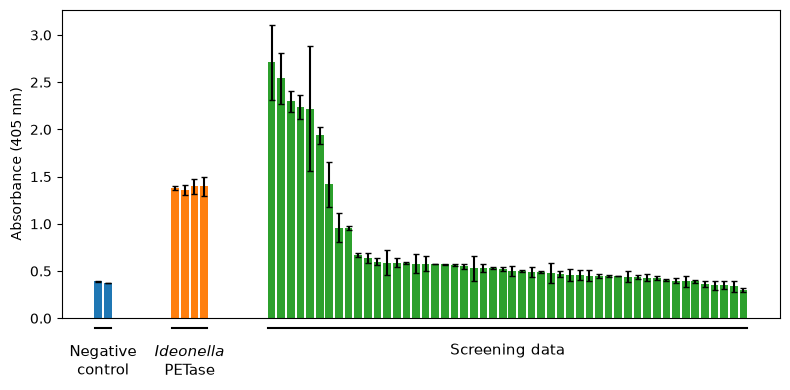

In [5]:
values = act

# x positions with gaps between groups
x1 = np.arange(2)
x2 = np.arange(4) + 8      # gap after first group
x3 = np.arange(50) + 18    # gap after second group
x = np.concatenate([x1, x2, x3])

fig, ax = plt.subplots(figsize=(8, 4))

# Group 1 (2 bars)
ax.bar(x1,values[:2],yerr=std[:2],width=.8,color='tab:blue',capsize=2,)

# Group 2 (4 bars)
ax.bar(x2,values[2:6],yerr=std[2:6],width=0.8,color='tab:orange',capsize=2,)

# Group 3 (50 bars)
ax.bar(x3,values[6:],yerr=std[6:],width=0.8,color='tab:green',capsize=2,)

# Optional: remove individual x tick labels
ax.set_xticks([])

# Group labels
groups = [(x1.mean(), 'Negative\ncontrol'),(x2.mean(), r'$\it{Ideonella}$' + '\nPETase'),(x3.mean(), 'Screening data')]
for xc, label in groups:
    ax.text(xc,-0.08,label,ha='center',va='top',transform=ax.get_xaxis_transform(),fontsize=11)

# Group brackets
for group in [x1, x2, x3]:
    ax.plot([group[0]-0.35, group[-1]+0.35],[-0.03, -0.03],transform=ax.get_xaxis_transform(),color='black',clip_on=False)

ax.set_ylabel('Absorbance (405 nm)')
plt.tight_layout()
fig.savefig(OUTPUT / 'screening_data.eps')
plt.show()

## 2. Figure 4B — reaction progress of purified proteins

Use the final 0–60-minute table, retaining the measured time-zero values. No background subtraction or normalization is introduced. R1 = clone 5, R2 = clone 75, and R3 = clone 97. Clone 79 shares the R2 sequence and is retained in the table but omitted from the final panel, following the source notebook.

In [6]:
# From: FIGURE_Four_Activity_Spreadsheet
data = """Time (Minutes)	NgCnt	Ideonella	clone5	clone75	clone79	clone97	Buffer
0	0.075	0.083	0.097	0.110	0.179	0.084	0.075
10	0.075	0.124	0.184	0.274	0.643	0.144	0.074
20	0.077	0.166	0.293	0.493	1.022	0.218	0.077
30	0.083	0.207	0.388	0.653	1.164	0.289	0.082
40	0.087	0.256	0.482	0.845	1.206	0.361	0.087
50	0.093	0.286	0.556	0.982	1.196	0.421	0.090
60	0.098	0.317	0.632	1.046	1.154	0.485	0.094
							
							
							
	0.00	0.00	0.01	0.01	0.03	0.00	0.01
	0.00	0.01	0.00	0.00	0.09	0.00	0.01
	0.00	0.02	0.01	0.04	0.16	0.00	0.01
	0.00	0.02	0.02	0.05	0.16	0.01	0.01
	0.00	0.02	0.03	0.10	0.20	0.02	0.01
	0.00	0.03	0.03	0.16	0.22	0.01	0.01
	0.00	0.03	0.05	0.17	0.24	0.00	0.01"""
data = [r.split('\t') for r in data.strip().split('\n')]

In [7]:
names = [c for c in data[0]][1:-1]
time = [int(r[0]) for r in data[1:8]]
neg = [float(r[1]) for r in data[1:8]]
wt = [float(r[2]) for r in data[1:8]]
c5 = [float(r[3]) for r in data[1:8]]
c75 = [float(r[4]) for r in data[1:8]]
c79 = [float(r[5]) for r in data[1:8]]
c97 = [float(r[6]) for r in data[1:8]]

negsd = [float(r[1]) for r in data[11:18]]
wtsd = [float(r[2]) for r in data[11:18]]
c5sd = [float(r[3]) for r in data[11:18]]
c75sd = [float(r[4]) for r in data[11:18]]
c79sd = [float(r[5]) for r in data[11:18]]
c97sd = [float(r[6]) for r in data[11:18]]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


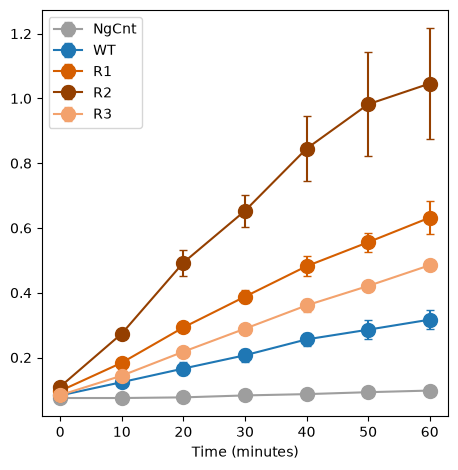

In [8]:
colors = ['#9E9E9E','#1F77B4','#F3A26D', '#D55E00', '#943F00']
act = [neg,wt,c5,c75,c79,c97]
std = [negsd,wtsd,c5sd,c75sd,c79sd,c97sd]

plt.errorbar(time,act[0],yerr=std[0],fmt='o-', capsize=3, label='NgCnt', markersize=10,color=colors[0])
plt.errorbar(time,act[1],yerr=std[1],fmt='o-', capsize=3, label='WT', markersize=10,color=colors[1])
plt.errorbar(time,act[2],yerr=std[2],fmt='o-', capsize=3, label='R1', markersize=10,color=colors[3])
plt.errorbar(time,act[3],yerr=std[3],fmt='o-', capsize=3, label='R2', markersize=10,color=colors[4])

plt.errorbar(time,act[5],yerr=std[5],fmt='o-', capsize=3, label='R3', markersize=10,color=colors[2])


plt.legend()
plt.gca().set_box_aspect(1)
plt.xlabel('Time (minutes)');
plt.tight_layout()
plt.savefig(OUTPUT / 'reaction_progress.eps')
plt.show()

### Clone labels

The original note maps lysate aliases 5 / 25 / 47 to purified clones 5 / 75 / 97 and paper labels R1 / R2 / R3. The pasted screening table uses IDs 1–10 and 61–100; those source IDs are preserved rather than silently relabeled.